In [45]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec

# Part I: simulation
### Setting the parameters

Scenario: ℵ simulations, each with exponentially increasing number _N_ of trials, _m_ doors, _p_ of which opened _at once_ by the host. $p\in[1,m-2]$.

In [2]:
ℵ=5
for i in np.arange(ℵ):
    N[i]=10**(i+1)#let's start with at least 10 draws
m=6
p=np.arange(1,m-1)#(m-1)-array to track the number of doors opened
N=np.ones(ℵ,dtype=np.int_)

### Prize-to-door assignments

In [4]:
#initialization of gamers' arrays
conservative_wfN=np.ones((ℵ,len(p)))#(ℵ,len(p)) matrix to record the fractions of wins as a function of (N,p) 
switcher_wfN=np.ones((ℵ,len(p)))#//
newcomer_wfN=np.ones((ℵ,len(p)))#//

for j in np.arange(ℵ):
    for k in np.arange(len(p)):
        sequence=np.ones((N[j],m),dtype=np.int_)#(N,m)-array for storage of the doors occupied by (car,goat_1,...,goat(m-1)), in this exact order
        arr=np.arange(m)
        
        #prize-to-door assignments
        for i in np.arange(N[j]):
            np.random.shuffle(arr)
            sequence[i]=arr
            
        #picks
        #(1) conservative
        conservative=np.random.randint(m,size=N[j])
        
        #(2) host
        host=np.ones((N[j],p[k]),dtype=np.int_)
        for i in np.arange(N[j]):
            #p random numbers drawn from those remaining upon ignoring the one alread picked by the player and the winning one. N.B.: the two may coincide
            a=np.random.default_rng().choice(len(sequence[i][(sequence[i]!=conservative[i]) & (sequence[i]!=sequence[i][0])]),size=p[k],replace=False)
            host[i]=sequence[i][(sequence[i]!=conservative[i]) & (sequence[i]!=sequence[i][0])][a]
        
        #(3) switcher
        switcher=np.ones(N[j],dtype=np.int_)
        for i in np.arange(N[j]):
            b=np.random.randint(m-p[k]-1)
            #sub-array of the elements in 'sequence[i]' not belonging to 'host[i]'
            values_sh, idx_A, idx_B = np.intersect1d(sequence[i],host[i],return_indices=True)
            sy_hn = np.delete(sequence[i],idx_A)#read 'sequence yes, host no'
            #sub-array of the elements in 'sequence[i]' not belonging to 'conservative[i]'
            values_sc, idx_C, idx_D = np.intersect1d(sequence[i],conservative[i],return_indices=True)
            sy_cn = np.delete(sequence[i],idx_C)
            #sub-array of the elements in 'sequence[i]' not belonging to either 'host[i]' or 'conservative[i]'
            sy_hn_cn = np.intersect1d(sy_hn,sy_cn)
            switcher[i] = sy_hn_cn[b]
        
        #(4) newcomer
        newcomer=np.ones(N[j],dtype=np.int_)
        for i in np.arange(N[j]):
            c=np.random.randint(m-p[k])
            values_sh, idx_A, idx_B = np.intersect1d(sequence[i],host[i],return_indices=True)
            sy_hn = np.delete(sequence[i],idx_A)#read 'sequence yes, host no'
            newcomer[i]=sy_hn[c]
            
        #Win counts
        conservative_wins_count=0
        for i in np.arange(N[j]):
            if sequence[i][0]==conservative[i]:
                conservative_wins_count += 1
        conservative_wins_fraction=conservative_wins_count/N[j]
        switcher_wins_count=0
        for i in np.arange(N[j]):
            if sequence[i][0]==switcher[i]:
                switcher_wins_count += 1
        switcher_wins_fraction=switcher_wins_count/N[j]
        newcomer_wins_counts=0
        for i in np.arange(N[j]):
            if sequence[i][0]==newcomer[i]:
                newcomer_wins_counts += 1
        newcomer_wins_fraction=newcomer_wins_counts/N[j]
        
        #win-fractions (for given N)
        conservative_wfN[j][k]=conservative_wins_fraction
        switcher_wfN[j][k]=switcher_wins_fraction
        newcomer_wfN[j][k]=newcomer_wins_fraction

# Part II: plots

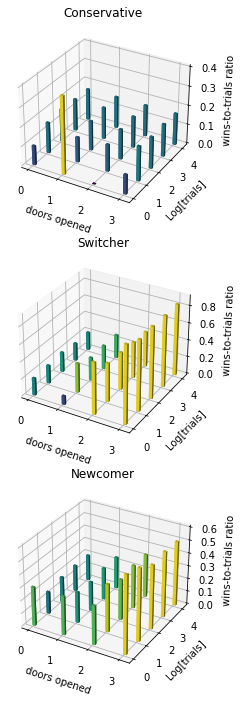

In [61]:
nrows, ncols = conservative_wfN.shape

xpos, ypos = np.meshgrid(np.arange(ncols), np.arange(nrows))
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)

dx = dy = 0.1
dz1 = conservative_wfN.flatten()
dz2 = switcher_wfN.flatten()
dz3 = newcomer_wfN.flatten()

# Normalize heights
norm1 = Normalize(vmin=dz1.min(), vmax=dz1.max())
norm2 = Normalize(vmin=dz2.min(), vmax=dz2.max())
norm3 = Normalize(vmin=dz3.min(), vmax=dz3.max())

# Map heights to colors
colors1 = cm.viridis(norm(dz1))
colors2 = cm.viridis(norm(dz2))
colors3 = cm.viridis(norm(dz3))

fig=plt.figure(figsize=(18,12))
gs = GridSpec(3, 3)

ax1 = fig.add_subplot(gs[0, 0], projection='3d')

ax1.bar3d(xpos, ypos, zpos, dx, dy, dz1, color=colors1)

ax1.set_xlabel("doors opened")
ax1.set_ylabel("Log[trials]")
ax1.set_zlabel("wins-to-trials ratio")
ax1.set_title("Conservative")

ax2 = fig.add_subplot(gs[1, 0], projection='3d')

ax2.bar3d(xpos, ypos, zpos, dx, dy, dz2, color=colors2)

ax2.set_xlabel("doors opened")
ax2.set_ylabel("Log[trials]")
ax2.set_zlabel("wins-to-trials ratio")
ax2.set_title("Switcher")

ax3 = fig.add_subplot(gs[2, 0], projection='3d')

ax3.bar3d(xpos, ypos, zpos, dx, dy, dz3, color=colors3)

ax3.set_xlabel("doors opened")
ax3.set_ylabel("Log[trials]")
ax3.set_zlabel("wins-to-trials ratio")
ax3.set_title("Newcomer")

plt.show()